# Exploration — Sample Submission

Fichier concerné : `data/GLC25_SAMPLE_SUBMISSION.csv`

Ce fichier définit le format attendu pour la soumission : une ligne par `surveyId` de test, avec une colonne `predictions` contenant une liste d'`speciesId` séparés par des espaces.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = '../data/'

submission = pd.read_csv(DATA_DIR + 'GLC25_SAMPLE_SUBMISSION.csv')
print('Shape:', submission.shape)
submission.head(10)

Shape: (14784, 2)


,surveyId,predictions
0,642,3301 7301 2436 4600 2860 10897
1,1792,2564 4888 6082 5015 987 3969 4157 8964 5494 71...
2,3256,10587 1082 9765 8078 2805 4647 9000 2796 5788 ...
3,3855,6677 844 344 9848 6340 366 6983 10787
4,4889,9118 2747 6532 4687 8028 3032 117 7742 10106 4...
5,5884,6828 8839 1374 10423 5249 531 10923
6,6955,9665 6809 6460 10378 11129
7,8956,3260 1986 339 10107 8289 6609 9941 1686 581 87...
8,9037,8356 2183 10510 10056 2444 9275 4764 4174 3667
9,9537,960 8285 7537 828 6771 8573 3469 6984 6076 489...


## 1. Structure

In [2]:
print(submission.dtypes)
print('\nValeurs manquantes:')
print(submission.isnull().sum())

surveyId        int64
predictions    object
dtype: object

Valeurs manquantes:
surveyId       0
predictions    0
dtype: int64


## 2. Analyse des prédictions (sample)

Nb espèces prédites — min: 5, max: 20, mean: 12.53


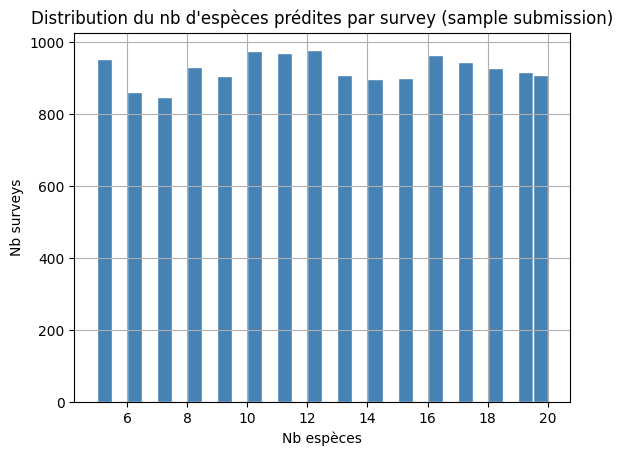

In [3]:
# Nombre d'espèces prédites par survey
n_preds = submission['predictions'].dropna().apply(lambda x: len(str(x).split()))

print(f'Nb espèces prédites — min: {n_preds.min()}, max: {n_preds.max()}, mean: {n_preds.mean():.2f}')

n_preds.hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution du nb d\'espèces prédites par survey (sample submission)')
plt.xlabel('Nb espèces')
plt.ylabel('Nb surveys')
plt.show()

In [4]:
# Vérifier que tous les surveyId du test sont présents
test_meta = pd.read_csv(DATA_DIR + 'GLC25_PA_metadata_test.csv')
test_surveys = test_meta['surveyId'].unique()

print(f'Surveys dans test metadata : {len(test_surveys)}')
print(f'Surveys dans sample submission : {submission["surveyId"].nunique()}')
print(f'Match complet : {set(test_surveys) == set(submission["surveyId"].values)}')

Surveys dans test metadata : 14784
Surveys dans sample submission : 14784
Match complet : True


## 3. Espèces les plus fréquentes dans le sample

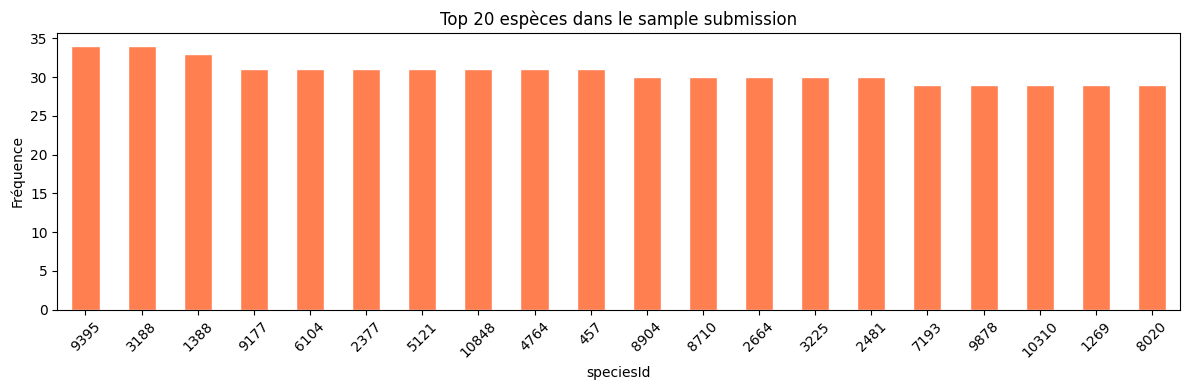

In [5]:
from collections import Counter

all_preds = []
for row in submission['predictions'].dropna():
    all_preds.extend(str(row).split())

species_counts = Counter(all_preds)
top_species = pd.Series(species_counts).sort_values(ascending=False).head(20)

top_species.plot(kind='bar', color='coral', edgecolor='white', figsize=(12, 4))
plt.title('Top 20 espèces dans le sample submission')
plt.xlabel('speciesId')
plt.ylabel('Fréquence')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()